Eigenvalues of A: [-1. -2.]


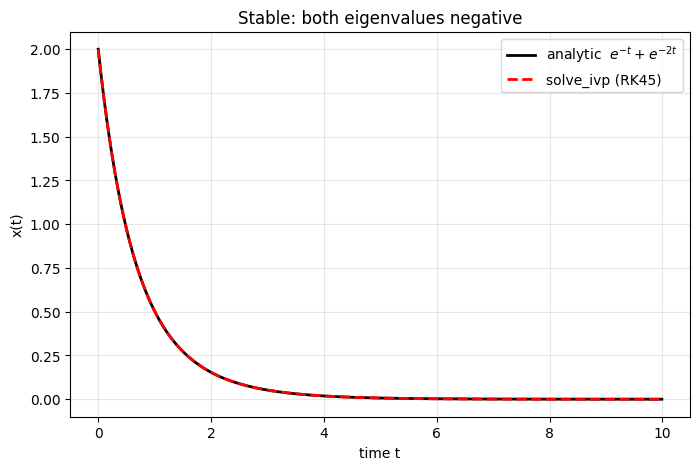

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# System: x'' + 3x' + 2x = 0, x(0)=2, x'(0)=-3
A = np.array([[0.0, 1.0],
              [-2.0, -3.0]])          # companion matrix

eigvals = np.linalg.eigvals(A)
print("Eigenvalues of A:", eigvals)   # should print [-2. -1.]

t = np.arange(0, 10, 0.01)
y0 = [2.0, -3.0]                      # [x(0), v(0)]

x_analytic = np.exp(-t) + np.exp(-2 * t)

def rhs(t, y):
    return A @ y                       # dy/dt = A y

sol = solve_ivp(rhs, [t[0], t[-1]], y0, t_eval=t, rtol=1e-8, atol=1e-10)

plt.figure(figsize=(8, 5))
plt.plot(t, x_analytic, 'k-', lw=2, label='analytic  $e^{-t}+e^{-2t}$')
plt.plot(sol.t, sol.y[0], 'r--', lw=2, label='solve_ivp (RK45)')
plt.xlabel('time t'); plt.ylabel('x(t)')
plt.legend(); plt.grid(alpha=0.3)
plt.title('Stable: both eigenvalues negative')
plt.show()